In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

# Data loading

In [2]:
dataset_zip_url = "https://people.csail.mit.edu/celiu/motionAnnotation/database/table.zip"
dataset_dir = "./table"

def load_images(image_path1, image_path2):
    """Loads two images and converts them to grayscale float32."""
    img1 = cv2.imread(image_path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image_path2, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        raise FileNotFoundError("Images not found at specified paths.")

    # gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    # gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    # return gray_img1, gray_img2
    
    return img1, img2

def load_mat(mat_path: str) -> tuple:
    mat = scipy.io.loadmat(mat_path)
    return mat['vx'], mat['vy']

dataset_path = "./table/frames/"
image_path1 = dataset_path + "sample 01.jpg"
image_path2 = dataset_path + "sample 02.jpg"
mat_path = 'table/flows/sample 01.mat'

img1, img2 = load_images(image_path1, image_path2)
print("Images loaded and preprocessed from downloaded dataset.")

Images loaded and preprocessed from downloaded dataset.


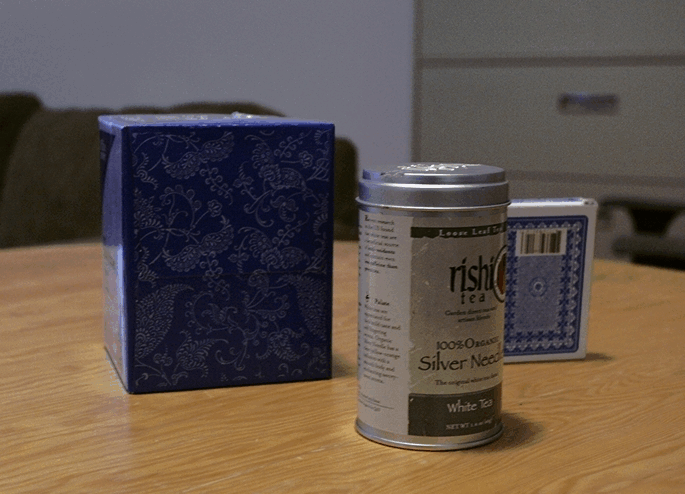

In [3]:
"""Stitched the frames together via an online tool to make a gif"""
from IPython.display import Image
Image(dataset_path + 'gif.gif')

# Solution
Include all code, results, and visualizations below.

**You are free to use OpenCV for image preprocessing, feature detection, and visualization, but make sure to implement all the core functions from scratch (Lucas-Kanade, Horn–Schunck, etc).**

## Lucas-Kanade Optical Flow Estimation

### Instructions (collapse)

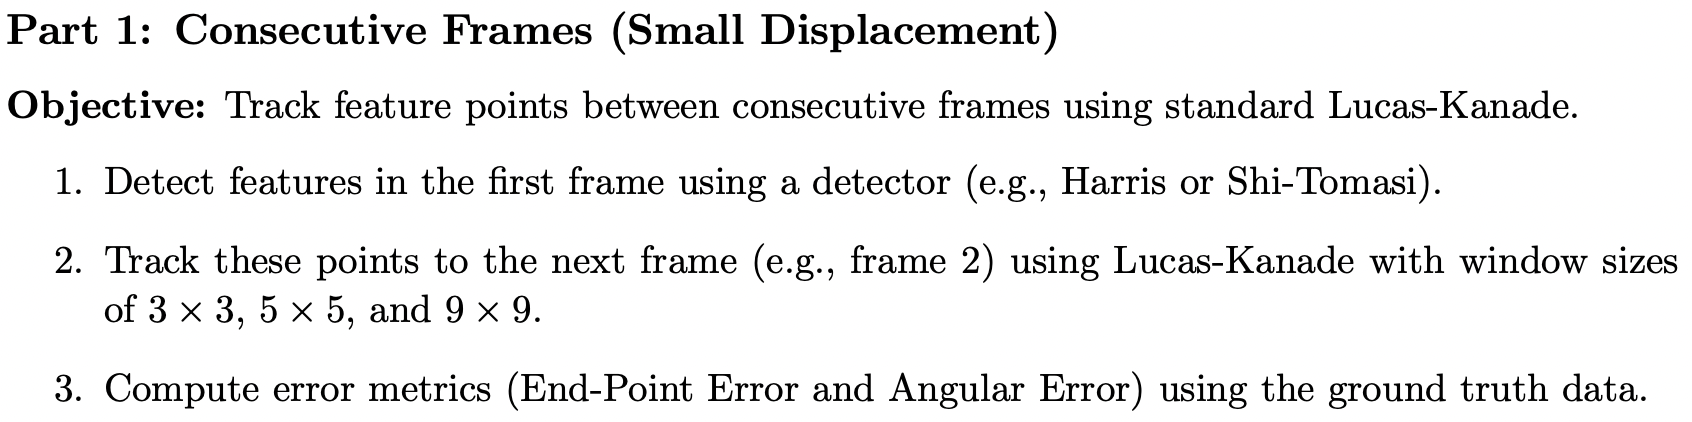
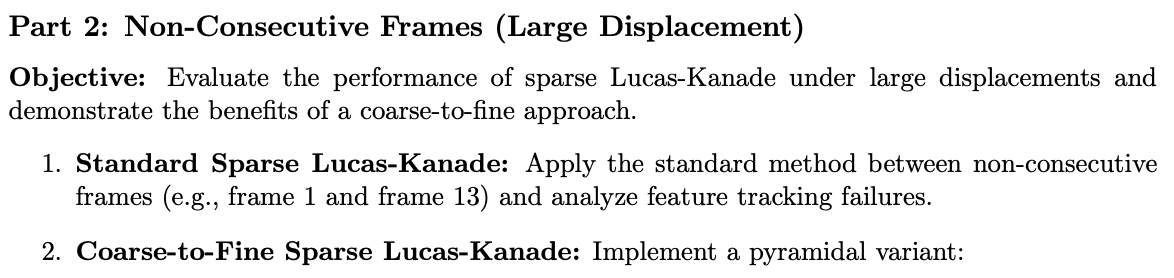
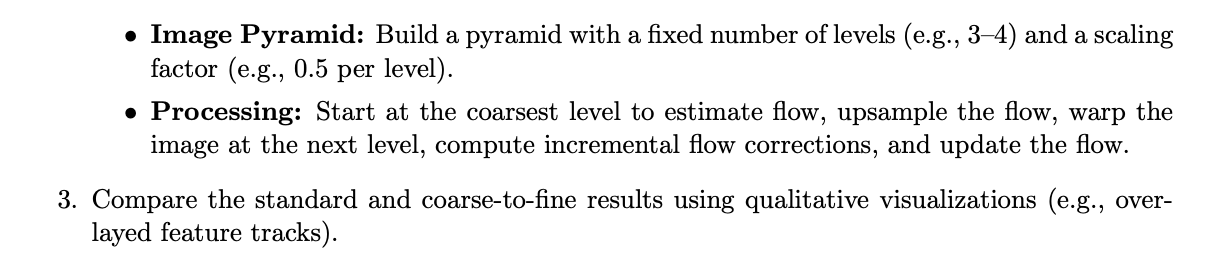

### Feature Detector

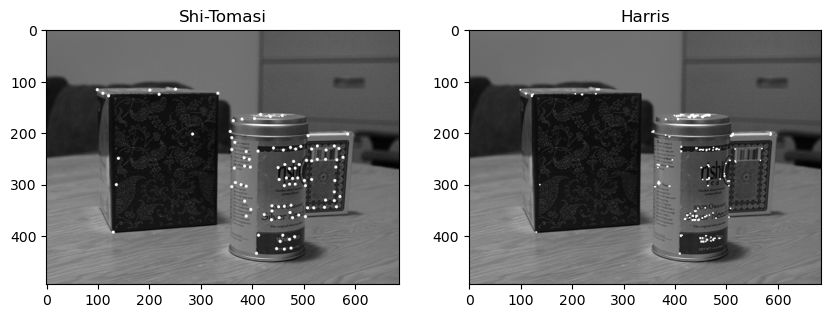

In [4]:
"""Determine which feature detector to use... visualize both and experiment with parameters"""

# Load ---------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
shi_tomasi_img = img1.copy()
harris_img = img1.copy()

# Shi-Tomasi --------------- https://docs.opencv.org/4.x/d4/d8c/tutorial_py_shi_tomasi.html
corners = cv2.goodFeaturesToTrack(shi_tomasi_img, 100, 0.01, 10)
corners = np.intp(corners)
for i in corners:
    x,y = i.ravel()
    cv2.circle(shi_tomasi_img, (x,y), 3, 255, -1)

# Harris ------------------- https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html 
dst = cv2.cornerHarris(harris_img, 2, 3, 0.04)
dst = cv2.dilate(dst,None)
harris_img_bgr = cv2.cvtColor(harris_img, cv2.COLOR_GRAY2BGR)
harris_img_bgr[dst > 0.05 * dst.max()] = [255, 255, 255]

# Plot ---------------------
axes[0].set_title('Shi-Tomasi')
axes[1].set_title('Harris')
axes[0].imshow(shi_tomasi_img, cmap='gray')
axes[1].imshow(harris_img_bgr, cmap='gray')

### Quantitative Assessment: Error Metrics

In [5]:
"""Endpoint and Angular Errors"""

def endpoint_error(est_flow, true_flow):
    """Euclidean distance"""
    return np.linalg.norm(est_flow - true_flow, axis=1)


def angular_error(est_flow, true_flow):
    """angular_error = arccos((u1*v1 + u2*v2) / (sqrt(u1^2 + u2^2) * sqrt(v1^2 + v2^2)))"""
    dot_product = np.sum(est_flow * true_flow, axis=1)
    magnitude1 = np.linalg.norm(est_flow, axis=1)
    magnitude2 = np.linalg.norm(true_flow, axis=1)
    mask = (magnitude1 * magnitude2) != 0
    angular_error = np.zeros_like(magnitude1)
    angular_error[mask] = np.arccos(dot_product[mask] / (magnitude1[mask] * magnitude2[mask]))
    angular_error[~mask] = np.pi / 2

    return np.degrees(angular_error)

In [6]:
"""Angular error test cases"""

# Test case 1: Exact match
assert np.allclose(angular_error(est_flow=np.array([[1.0, 0.0], [0.0, 1.0]]), true_flow=np.array([[1.0, 0.0], [0.0, 1.0]])), [0., 0.])

# Test case 2: Orthogonality
assert np.allclose(angular_error(est_flow=np.array([[1.0, 0.0], [0.0, 1.0]]), true_flow=np.array([[0.0, 1.0], [1.0, 0.0]])), [90., 90.])

# Test case 3: Zero vectors
assert np.allclose(angular_error(est_flow=np.array([[0.0, 0.0], [1.0, 1.0]]), true_flow=np.array([[1.0, 1.0], [0.0, 0.0]])), [90., 90.])

# Test case 4: Random vectors
assert np.allclose(angular_error(est_flow=np.array([[1.0, 2.0], [3.0, 4.0]]), true_flow=np.array([[2.0, 1.0], [4.0, 3.0]])), [36.86989765, 16.26020471])

### Qualitative Assessment: Plots

In [7]:
"""Quiver plot for Horn-Schunk"""
def quiver_plot(true_flow, est_flow):
    y, x = np.mgrid[0:494:10, 0:685:10]  # Sample every 10th pixel

    # True flow ------------------------------
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.quiver(x, y, true_flow[::10, ::10, 0], true_flow[::10, ::10, 1], color='r', scale=50)
    plt.title("True Flow")
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal')  # Maintain aspect ratio

    # Estimated flow -------------------------
    plt.subplot(1, 2, 2)
    plt.quiver(x, y, est_flow[::10, ::10, 0], est_flow[::10, ::10, 1], color='b', scale=50)
    plt.title("Estimated Flow")
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal')  # Maintain aspect ratio

    plt.tight_layout()
    plt.show()

In [8]:
"""Feature overlay plot for Lucas-Kanade"""
def plot_overlay(true_flow, fts1, fts2):
    # Red = Predicted position // Green = Actual position // Lines = Predicted movement
    gfts = fts1 + true_flow.astype(int)
    visualization = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    for _, (old, new, gnew) in enumerate(zip(fts1, fts2, gfts)):
        a, b = new.ravel().astype(int)
        c, d = old.ravel().astype(int)
        e, f = gnew.ravel().astype(int)
        visualization = cv2.circle(visualization, (a, b), 3, (255, 0, 0), -1)           # Estimated Position
        visualization = cv2.line(visualization, (a, b), (c, d), (255, 0, 0), 2)         # Estimated Movement
        visualization = cv2.circle(visualization, (e, f), 3, (102, 255, 102), -1)       # Ground Truth Position
        visualization = cv2.line(visualization, (e, f), (c, d), (102, 255, 102), 2)     # Ground Truth Movement
    plt.figure(figsize=(6, 4))
    plt.imshow(visualization)

In [9]:
"""Color-coded map for... fun?"""
def color_coded_map(true_flow, est_flow):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # True flow ------------------------------
    axs[0].imshow(np.sqrt(true_flow[:, :, 0]**2 + true_flow[:, :, 1]**2), cmap='jet')
    axs[0].set_title("True Flow")

    # Estimated flow -------------------------
    axs[1].imshow(np.sqrt(est_flow[:, :, 0]**2 + est_flow[:, :, 1]**2), cmap='jet')
    axs[1].set_title("Estimated Flow")

    # Plots ----------------------------------
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(plt.cm.ScalarMappable(cmap='jet'), cax=cbar_ax)
    plt.show()

### Lucas Kanade: Consecutive Frames [CV2]

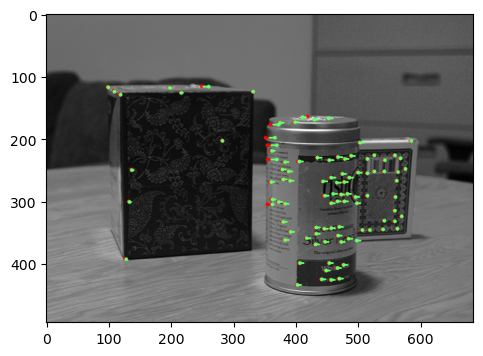

In [10]:
"""Lucas-Kanade Tracker

It's a bit messy
Ideally I would've just returned the estimated optical flow, but I needed the feature point data for plotting
"""
def lucas_kanade_tracker(image_path1: str, image_path2: str, window_size: tuple, mat_path: str, plot: bool=False):
    img1, img2 = load_images(image_path1, image_path2)
    
    # Shi-Tomasi Feature Extractor ------------
    fts1 = cv2.goodFeaturesToTrack(img1, maxCorners=100, qualityLevel=0.01, minDistance=10)
    
    # Lucas-Kanade Optical Flow --------------- https://docs.opencv.org/3.4/dc/d6b/group__video__track.html#ga473e4b886d0bcc6b65831eb88ed93323
    fts2, status, _ = cv2.calcOpticalFlowPyrLK(prevImg=img1, nextImg=img2, prevPts=fts1, nextPts=None, winSize=window_size, maxLevel=2, criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 3, 0.001))
    fts1 = fts1[status == 1].astype(int)
    fts2 = fts2[status == 1].astype(int)

    # Model evaluation (EPE, AE) --------------
    vx, vy = load_mat(mat_path)
    est_flow = fts2 - fts1
    true_flow = np.array([(vx[ft[1], ft[0]], vy[ft[1], ft[0]]) for ft in fts2])

    # Visualizing optical flow ----------------
    if plot:
        plot_overlay(true_flow, fts1, fts2)
    
    return est_flow, true_flow

image_path1 = dataset_path + "sample 01.jpg"
image_path2 = dataset_path + "sample 02.jpg"
mat_path = 'table/flows/sample 01.mat'

est_flow, true_flow = lucas_kanade_tracker(image_path1, image_path2, (9, 9), mat_path, plot=True)

In [11]:
"""Evaluation on all 13 frames"""

print("Lucas-Kanade Tracker")

lk_results = []

for window_size in [(3,3), (5,5), (9,9)]:
    for i in range(12):
        image_path1 = dataset_path + f"sample {(i+1):02d}.jpg"
        image_path2 = dataset_path + f"sample {(i+2):02d}.jpg"
        mat_path = f"table/flows/sample {(i+1):02d}.mat"
        est_flow, true_flow = lucas_kanade_tracker(image_path1, image_path2, window_size, mat_path)
        epe = endpoint_error(est_flow, true_flow).mean()
        ae = angular_error(est_flow, true_flow).mean()
        lk_results.append({"frame": f"{i+1}-{i+2}", "window_size": window_size, "epe": round(epe, 2), "ae": round(ae, 2)})

lk_results = pd.DataFrame(lk_results)
lk_results.T

Lucas-Kanade Tracker


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
frame,1-2,2-3,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,...,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13
window_size,"(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)",...,"(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)"
epe,2.54,4.57,5.58,5.37,7.49,3.71,3.12,3.14,2.41,2.68,...,3.22,3.7,3.42,2.38,1.39,2.19,1.47,1.43,1.64,1.43
ae,25.57,41.24,42.83,33.61,32.26,27.11,37.58,34.19,35.63,21.87,...,26.94,26.72,20.97,23.88,31.85,27.86,31.79,13.15,14.45,17.66


### Lucas Kanade: Consecutive Frames [from scratch]

In [12]:
def lucas_kanade_tracker2(img1, img2, fts, window_size):   
    
    # Gradients ----------------------------- https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html
    Ix = cv2.Sobel(img1, cv2.CV_32F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img1, cv2.CV_32F, 0, 1, ksize=3)
    It = img2 - img1

    # Initialize optical flow vectors -------
    flow = np.zeros((len(fts), 2), dtype=np.float32)

    # Iterate over features -----------------
    for i, ft in enumerate(fts):
        
        # Window around feature -------------
        wx, wy = window_size
        wIx = Ix[ft[0][1]-wy//2:ft[0][1]+wy//2+1, ft[0][0]-wx//2:ft[0][0]+wx//2+1]
        wIy = Iy[ft[0][1]-wy//2:ft[0][1]+wy//2+1, ft[0][0]-wx//2:ft[0][0]+wx//2+1]
        wIt = It[ft[0][1]-wy//2:ft[0][1]+wy//2+1, ft[0][0]-wx//2:ft[0][0]+wx//2+1]

        # Least squares solver ---------------
        A = np.vstack((wIx.flatten(), wIy.flatten())).T
        b = -wIt.flatten()
        u, v = np.linalg.lstsq(A, b, rcond=None)[0]
        
        flow[i] = [u, v]

    return flow

image_path1 = dataset_path + "sample 01.jpg"
image_path2 = dataset_path + "sample 02.jpg"
mat_path = 'table/flows/sample 01.mat'
vx, vy = load_mat(mat_path)
img1, img2 = load_images(image_path1, image_path2)
fts1 = cv2.goodFeaturesToTrack(img1, maxCorners=100, qualityLevel=0.01, minDistance=10).astype(int)  # Shi-Tomasi

est_flow = lucas_kanade_tracker2(img1, img2, fts1, (9, 9))
true_flow = np.array([(vx[ft[1], ft[0]], vy[ft[1], ft[0]]) for ft in fts1.reshape(-1, 2)])

In [13]:
"""Evaluation on all 13 frames"""

print("Lucas-Kanade Tracker (from scratch)")

lk_results = []

for window_size in [(3,3), (5,5), (9,9)]:
    for i in range(12):
        image_path1 = dataset_path + f"sample {(i+1):02d}.jpg"
        image_path2 = dataset_path + f"sample {(i+2):02d}.jpg"
        mat_path = f"table/flows/sample {(i+1):02d}.mat"
        
        vx, vy = load_mat(mat_path)
        img1, img2 = load_images(image_path1, image_path2)
        fts1 = cv2.goodFeaturesToTrack(img1, maxCorners=100, qualityLevel=0.01, minDistance=10).astype(int)  # Shi-Tomasi

        est_flow = lucas_kanade_tracker2(img1, img2, fts1, (9, 9))
        true_flow = np.array([(vx[ft[1], ft[0]], vy[ft[1], ft[0]]) for ft in fts1.reshape(-1, 2)])

        epe = endpoint_error(est_flow, true_flow).mean()
        ae = angular_error(est_flow, true_flow).mean()

        lk_results.append({"frame": f"{i+1}-{i+2}", "window_size": window_size, "epe": round(epe, 2), "ae": round(ae.astype(float), 2)})

lk_results = pd.DataFrame(lk_results)
lk_results.T

Lucas-Kanade Tracker (from scratch)


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
frame,1-2,2-3,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,...,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13
window_size,"(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)",...,"(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)"
epe,5.42,6.21,6.21,5.9,6.07,5.73,4.79,4.73,4.26,4.06,...,6.21,5.9,6.07,5.73,4.79,4.73,4.26,4.06,3.13,2.54
ae,111.86,110.3,112.69,123.45,117.1,123.46,121.71,125.17,120.39,114.41,...,112.69,123.45,117.1,123.46,121.71,125.17,120.39,114.41,98.37,118.28


### Lucas-Kanade: Non-Consecutive Frames

Feature tracking failures 
----- 
red = projected flow 
green = projected position 


Optical flow vectors 
-----
Mean displacement: [3.08, 2.32]
Standard deviation: [38.1, 42.55]


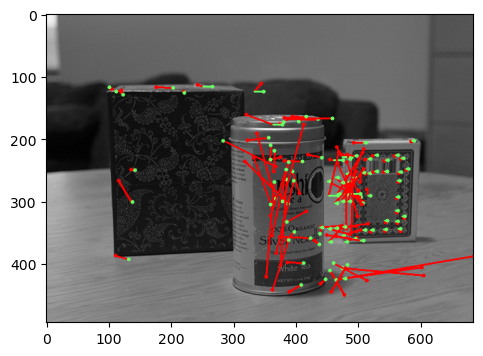

In [14]:
"""Standard Sparse Lucas-Kanade [cv2]

I initially tried with my implementation (without CV2) but the vectors magnitudes were strangely too small. 
I'll continue using the cv2 implementation for the sake of having a meaningful comparison

- Using the tracker on the first and last frames yielded visually poor results. 
- I don't have a way to compute the EPE and AE metrics as the ground truth data is for consecutive frames, 
  but the optical flow vectors had substantial variance in their displacement which indicates uncertainty
- Visually the lines are all over the place and are intuitively incorrect
- It seems features in the foreground (closer to the camera) are more incorrect, possibly due to increased motion flow

"""
image_path1 = dataset_path + "sample 01.jpg"
image_path2 = dataset_path + "sample 13.jpg"

print("Feature tracking failures \n----- \nred = projected flow \ngreen = projected position \n\n")
est_flow, _ = lucas_kanade_tracker(image_path1, image_path2, (9, 9), mat_path, plot=True)

print("Optical flow vectors \n-----")
print(f"Mean displacement: {np.mean(est_flow, axis=0).tolist()}")
print(f"Standard deviation: {np.std(est_flow, axis=0).round(2).tolist()}")

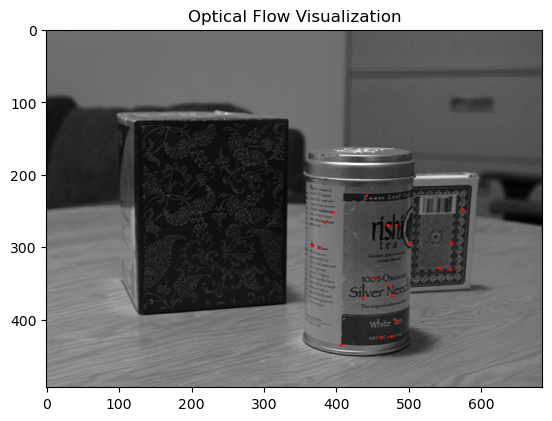

In [15]:
"""Without the CV2 Lucas-Kanade... the vector magnitudes are too small to be meaningful"""
def visualize_flow_as_vectors(img, flow, features):
    plt.imshow(img, cmap='gray')
    
    for i in range(0, len(features), 5):
        x, y = features[i]
        dx, dy = flow[i]
        plt.arrow(x, y, dx, dy, color='red', head_width=2, head_length=3)
    
    plt.title("Optical Flow Visualization")
    plt.show()

img1, img2 = load_images(image_path1, image_path2)
fts1 = cv2.goodFeaturesToTrack(img1, maxCorners=100, qualityLevel=0.01, minDistance=10).astype(int)  # Shi-Tomasi

est_flow = lucas_kanade_tracker2(img1, img2, fts1, (9, 9))

visualize_flow_as_vectors(img1, est_flow, fts1.reshape(-1, 2))

### Lucas-Kanade: Coarse-to-fine

In [16]:
"""Coarse-to-fine Lucas-Kanade on non-consecutive image frames"""

def pyramid(img, num_levels=3, scaling_factor=0.5):
    temp_img = [img]
    for _ in range(1, num_levels):
        img = cv2.resize(img, None, fx=scaling_factor, fy=scaling_factor, interpolation=cv2.INTER_LINEAR)
        temp_img.append(img)
    return temp_img


def lucas_kanade_tracker3(img1, img2, window_size):
    """Essentially the same as lucas_kanade_tracker2 but with all the coarse image points as feature points"""
    # Gradients ----------------------------- https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html
    Ix = cv2.Sobel(img1, cv2.CV_32F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img1, cv2.CV_32F, 0, 1, ksize=3)
    It = img2 - img1
    
    # Initialize optical flow vectors ------------
    flow = np.zeros((*img1.shape, 2), dtype=np.float32)

    # Iterate over points ------------------------
    for y in range(window_size[0], img1.shape[0] - window_size[0]):
        for x in range(window_size[1], img1.shape[1] - window_size[1]):
            # Window around point ----------------
            wIx = Ix[y-window_size[0]:y+window_size[0]+1, x-window_size[1]:x+window_size[1]+1]
            wIy = Iy[y-window_size[0]:y+window_size[0]+1, x-window_size[1]:x+window_size[1]+1]
            wIt = It[y-window_size[0]:y+window_size[0]+1, x-window_size[1]:x+window_size[1]+1]

            # Least squares solver ---------------
            A = np.vstack((wIx.flatten(), wIy.flatten())).T
            b = -wIt.flatten()
            # u, v = np.linalg.lstsq(A, b, rcond=None)[0]
            # flow[i] = [u, v]
            if np.linalg.matrix_rank(A) == 2:
                flow_vector = np.linalg.lstsq(A, b, rcond=None)[0]
                flow[y, x] = flow_vector

    return flow


def c2f_lucas_kanade_tracker(image_path1, image_path2, window_size, num_levels=3, scaling_factor=0.5):
    """Coarse-to-fine Lucas-Kanade optical flow tracker with pyramidal approach"""
    img1, img2 = load_images(image_path1, image_path2)

    # Build pyramids ----------------------------------------
    pyr1 = pyramid(img1, num_levels, scaling_factor)
    pyr2 = pyramid(img2, num_levels, scaling_factor)

    # Initialize optical flow vectors -----------------------
    flow = np.zeros((pyr1[-1].shape[0], pyr1[-1].shape[1], 2), dtype=np.float32)

    for level in range(num_levels-1, -1, -1):
        # Rescale flow to current resolution -----------------
        flow = cv2.resize(flow, (pyr1[level].shape[1], pyr1[level].shape[0]), interpolation=cv2.INTER_LINEAR)

        # Warp the next frame using the current estimate -----
        h, w = pyr1[level].shape
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        map_x = (x + flow[..., 0]).astype(np.float32)
        map_y = (y + flow[..., 1]).astype(np.float32)
        warped_img2 = cv2.remap(pyr2[level], map_x, map_y, interpolation=cv2.INTER_LINEAR)

        # Compute flow at the current resolution -------------
        flow += lucas_kanade_tracker3(pyr1[level], warped_img2, window_size)

    return flow

flow = c2f_lucas_kanade_tracker(image_path1, image_path2, window_size, 2, 0.5)

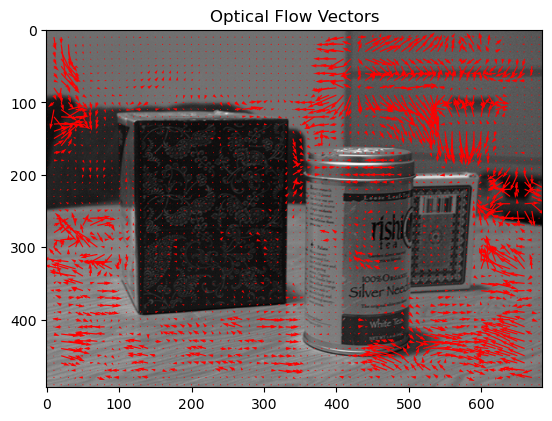

In [17]:
"""Quiver plot"""
img1, img13 = load_images(image_path1, image_path2)

fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))

X, Y = np.meshgrid(np.arange(0, flow.shape[1], 10), np.arange(0, flow.shape[0], 10))
U = flow[Y, X, 0]
V = flow[Y, X, 1]
ax.quiver(X, Y, U, V, color='red')

ax.set_title('Optical Flow Vectors')

# print("Optical flow vectors \n-----")
# print(f"Mean displacement: {np.mean(est_flow, axis=0).astype.round(2)}")
# print(f"Standard deviation: {np.std(est_flow, axis=0).astype.round(2)}")
plt.show()

## Horn-Schunck Optical Flow

### Instructions

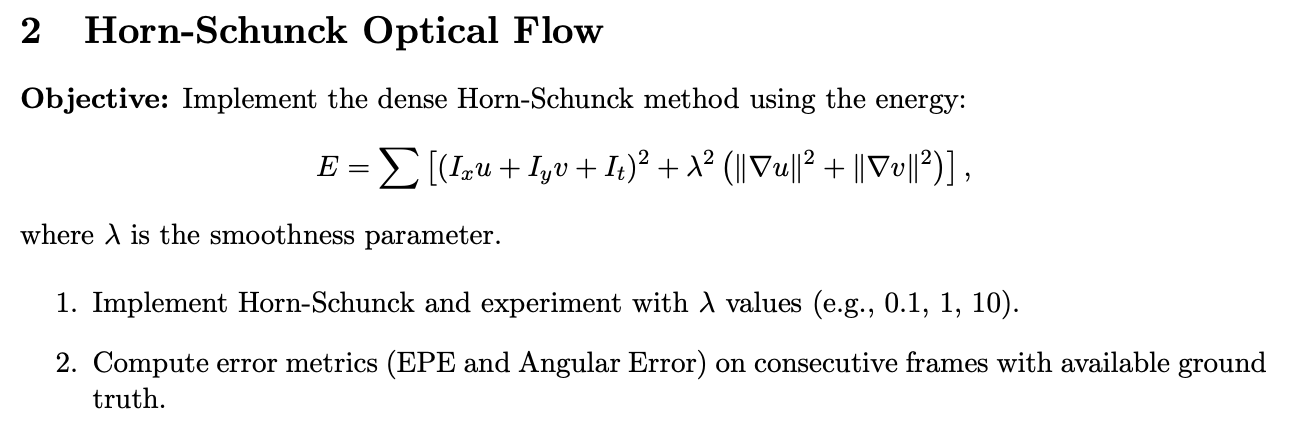

### Horn-Schunck: Implementation

In [18]:
# Convolutions - https://github.com/scivision/pyoptflow/blob/main/src/pyoptflow/hornschunck.py
# Approximation via Taylor series - https://github.com/ChanukaRavishan/Optical-flow-Horn-Schunk/blob/master/Taylorseries.py

hs_kernel = np.array([[1 / 12, 1 / 6, 1 / 12], [1 / 6, 0, 1 / 6], [1 / 12, 1 / 6, 1 / 12]])

def horn_schunck_tracker(image_path1, image_path2, lambda_, max_iter=100, epsilon=1e-6):
    img1, img2 = load_images(image_path1, image_path2)
    
    # Gradients ----------------------------- https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html
    Ix = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)
    It = img2.astype(np.float64) - img1.astype(np.float64)

    # Initialize optical flow vectors ------------
    u = np.zeros_like(img1, dtype=np.float64)
    v = np.zeros_like(img1, dtype=np.float64)

    # Iterate over points ------------------------
    # for _ in range(max_iter):
    #     u_avg = cv2.blur(u, (3, 3))
    #     v_avg = cv2.blur(v, (3, 3))

    #     A = Ix**2 + Iy**2 + lambda_**2
    #     B = -(Ix*It + Iy*(It + Ix*u_avg + Iy*v_avg))
    #     C = lambda_**2

    #     u_new = u_avg - (Ix*B - lambda_**2*(u - u_avg)) / A
    #     v_new = v_avg - (Iy*B - lambda_**2*(v - v_avg)) / A

    #     u = u_new
    #     v = v_new

    # flow = np.stack((u, v), axis=-1)
    # return flow
    # for _ in range(max_iter):
    #     for y in range(img1.shape[0]):
    #         for x in range(img1.shape[1]):
    #             # Compute local constraints
    #             A11 = Ix[y, x]**2 + Iy[y, x]**2
    #             A12 = Ix[y, x]*Iy[y, x]
    #             A22 = Iy[y, x]**2 + Ix[y, x]**2
    #             b1 = -Ix[y, x]*It[y, x]
    #             b2 = -Iy[y, x]*It[y, x]

    #             # Compute flow updates
    #             u_update = (A12*b2 - A22*b1) / (A11*A22 - A12**2)
    #             v_update = (A11*b1 - A11*b2) / (A11*A22 - A12**2)

    #             # Update flow field
    #             flow[y, x, 0] += lambda_ * u_update
    #             flow[y, x, 1] += lambda_ * v_update

    #     return flow
    
    for _ in range(max_iter):
        u_avg = scipy.signal.convolve2d(u, hs_kernel, "same")
        v_avg = scipy.signal.convolve2d(v, hs_kernel, "same")

        # Update step -----------------------------
        # min energy, E = sum(Ix*u + Iy*v + It)^2 + lambda^2 (||du||^2 + ||dv||^2)
        # der = (Ix*u + Iy*v + It)**2 + lambda_**2 * (np.linalg.norm(u - u_avg)**2 + np.linalg.norm(v - v_avg)**2)
        # der = (Ix*u + Iy*v + It)**2 + lambda_**2 * (np.linalg.norm(u - u_avg)**2 + np.linalg.norm(v - v_avg)**2)
        der = (Ix * u_avg + Iy * v_avg + It) / (lambda_ ** 2 + Ix ** 2 + Iy ** 2)
        # der = (Ix * u_avg + Iy * v_avg + It)**2 / (lambda_ ** 2 + u_avg ** 2 + v_avg ** 2)
        u = np.round(u_avg - Ix*der, 5)
        v = np.round(v_avg - Iy*der, 5)

        # Check for convergence -------------------
        if np.linalg.norm(u - u_avg) < epsilon and np.linalg.norm(v - v_avg) < epsilon:
            break
    return np.stack((u, v), axis=-1) 

image_path1 = dataset_path + "sample 01.jpg"
image_path2 = dataset_path + "sample 02.jpg"
mat_path = 'table/flows/sample 01.mat'
true_flow = np.stack(load_mat(mat_path), axis=-1)
est_flow = horn_schunck_tracker(image_path1, image_path2, 0.1)

### Horn-Schunck: Plots

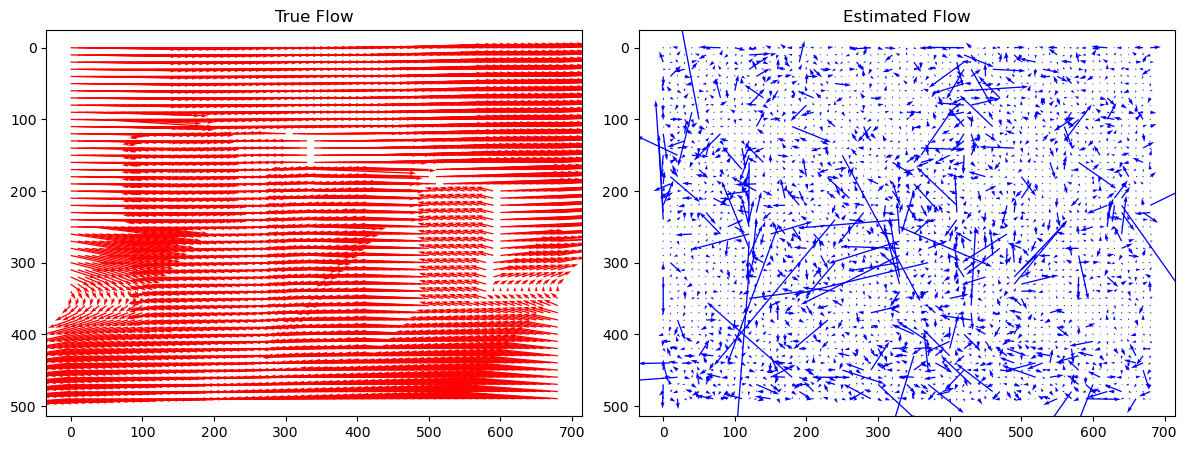

In [19]:
"""Quiver plots"""
quiver_plot(true_flow, est_flow)

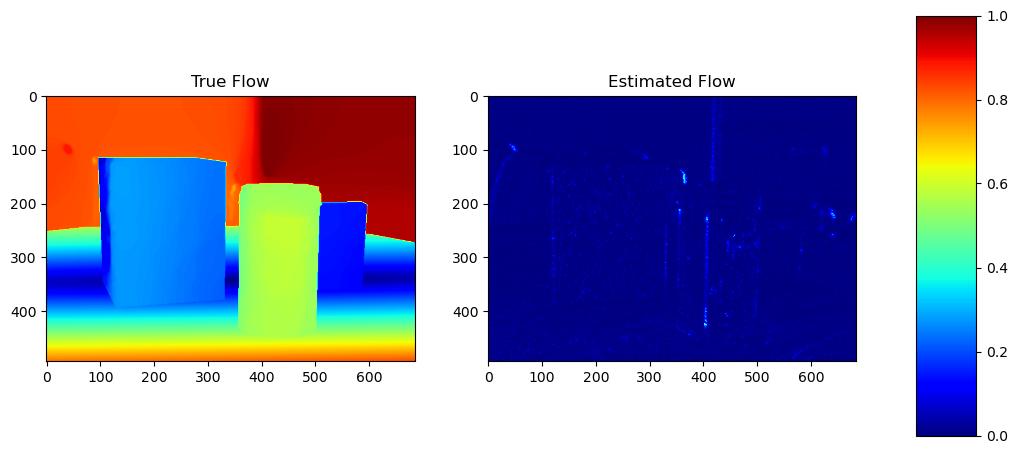

In [20]:
"""Color-coded map"""
color_coded_map(true_flow, est_flow)

### Horn-Schunck: Evaluation

In [21]:
"""Evaluate Horn-Schunk Model"""

N_FRAMES = 13
hs_results = []

print("Horn-Schunk Tracker")

for lambda_ in [0.01, 0.1, 1]:
    for i in range(N_FRAMES - 1):
        image_path1 = dataset_path + f"sample {(i+1):02d}.jpg"
        image_path2 = dataset_path + f"sample {(i+2):02d}.jpg"
        mat_path = f"table/flows/sample {(i+1):02d}.mat"
        
        est_flow = horn_schunck_tracker(image_path1, image_path2, lambda_=lambda_)
        
        vx, vy = load_mat(mat_path)
        true_flow = np.stack((vx, vy), axis=-1) 
        
        epe = endpoint_error(est_flow, true_flow).mean().round(2)
        ae = angular_error(est_flow, true_flow).mean().round(2)
        
        hs_results.append({"frame": f"{i+1}-{i+2}", "lambda": lambda_, "epe": epe, "ae": ae})
        
hs_results = pd.DataFrame(hs_results)
hs_results.T

Horn-Schunk Tracker


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
frame,1-2,2-3,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,...,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13
lambda,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
epe,106.52,128.84,141.3,136.1,131.79,135.27,141.31,142.18,140.65,134.36,...,140.04,134.51,130.43,134.02,140.22,140.87,139.46,133.19,127.44,124.63
ae,87.03,87.53,87.31,87.36,88.24,87.47,87.39,87.53,87.81,87.28,...,87.1,87.12,88.06,87.22,87.17,87.26,87.53,87.04,85.98,86.34


## Discussion

### Instructions

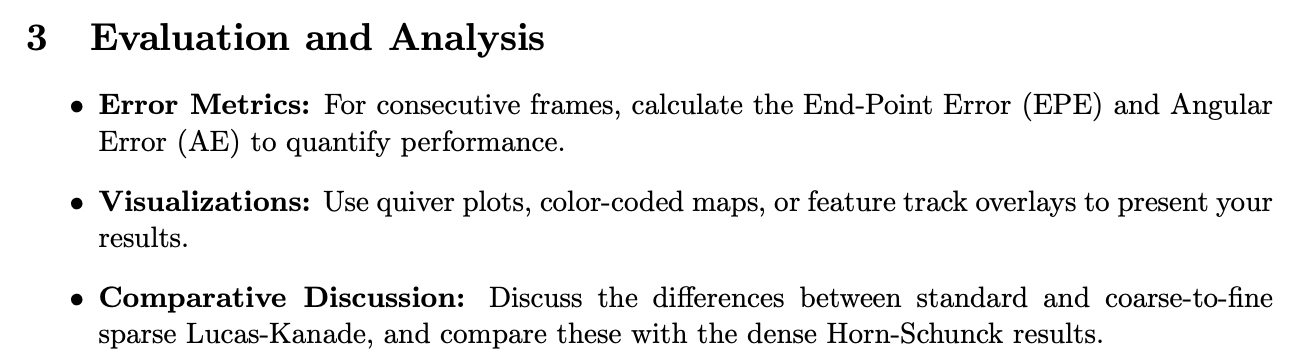

### Lucas-Kanade v Horn-Schunck

In [22]:
lk_results.T

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
frame,1-2,2-3,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,...,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13
window_size,"(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)","(3, 3)",...,"(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)","(9, 9)"
epe,5.42,6.21,6.21,5.9,6.07,5.73,4.79,4.73,4.26,4.06,...,6.21,5.9,6.07,5.73,4.79,4.73,4.26,4.06,3.13,2.54
ae,111.86,110.3,112.69,123.45,117.1,123.46,121.71,125.17,120.39,114.41,...,112.69,123.45,117.1,123.46,121.71,125.17,120.39,114.41,98.37,118.28


In [23]:
hs_results.T

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
frame,1-2,2-3,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,...,3-4,4-5,5-6,6-7,7-8,8-9,9-10,10-11,11-12,12-13
lambda,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
epe,106.52,128.84,141.3,136.1,131.79,135.27,141.31,142.18,140.65,134.36,...,140.04,134.51,130.43,134.02,140.22,140.87,139.46,133.19,127.44,124.63
ae,87.03,87.53,87.31,87.36,88.24,87.47,87.39,87.53,87.81,87.28,...,87.1,87.12,88.06,87.22,87.17,87.26,87.53,87.04,85.98,86.34


Please see the report for the full discussion